<a href="https://colab.research.google.com/github/jentsang/BreastCancerDiagnostic/blob/main/analysis_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import numpy as np
from sklearn.cluster import KMeans

In [15]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [16]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [17]:
df.shape

(569, 33)

In [18]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [19]:
# proportion of M = malignant, B = benign
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [20]:
# clean data to drop the id and unnamed (have NaNs) column
df.drop('id',axis=1,inplace=True)
df.drop('Unnamed: 32',axis=1,inplace=True)

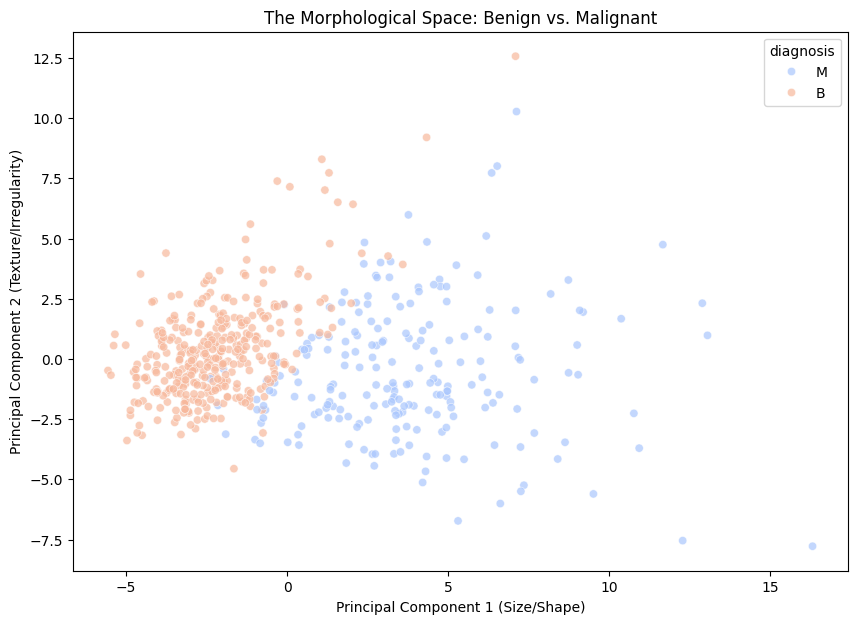

In [21]:
# PCA
# 1. Scale data (Essential for PCA/Clustering!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('diagnosis', axis=1))

# 2. PCA to 2D
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# 3. Plotting
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=df['diagnosis'], palette='coolwarm', alpha=0.7)
plt.title("The Morphological Space: Benign vs. Malignant")
plt.xlabel("Principal Component 1 (Size/Shape)")
plt.ylabel("Principal Component 2 (Texture/Irregularity)")
plt.show()

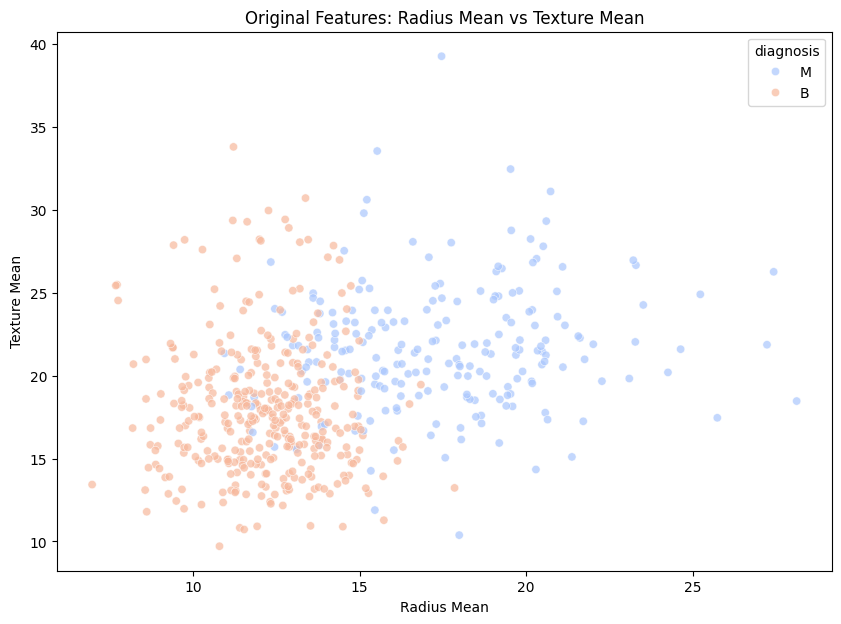

In [26]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['radius_mean'],
    y=df['texture_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Radius Mean vs Texture Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.show()

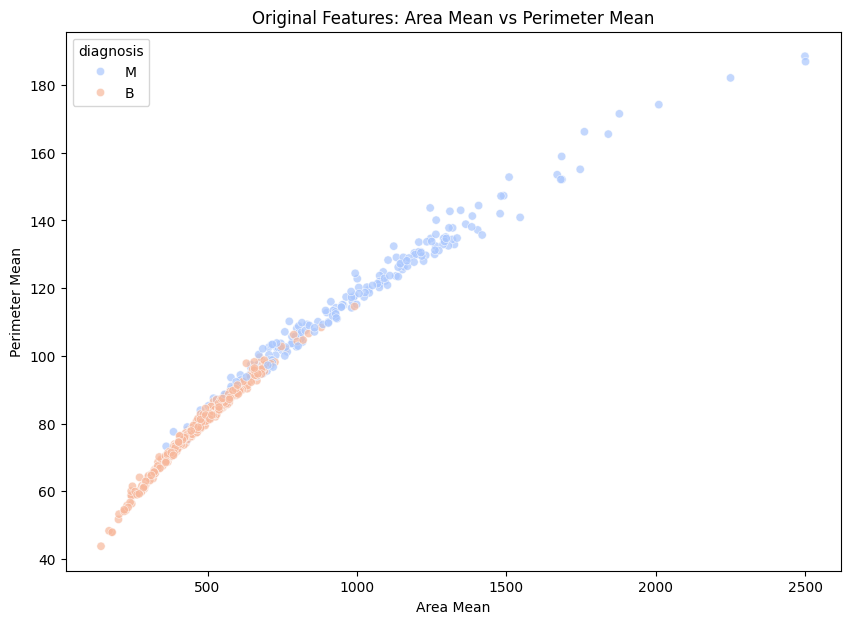

In [32]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['area_mean'],
    y=df['perimeter_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Area Mean vs Perimeter Mean")
plt.xlabel("Area Mean")
plt.ylabel("Perimeter Mean")
plt.show()

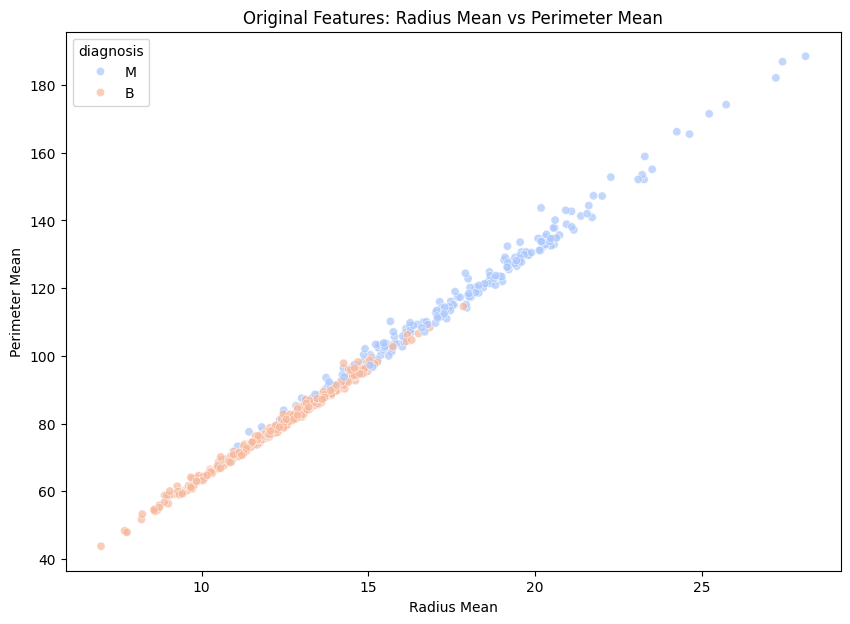

In [31]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['radius_mean'],
    y=df['perimeter_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Radius Mean vs Perimeter Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Perimeter Mean")
plt.show()

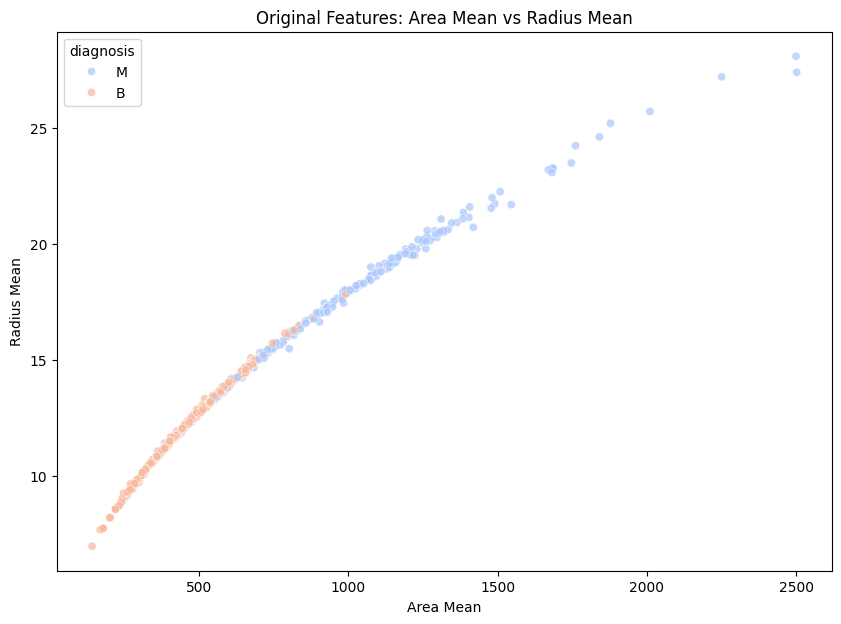

In [30]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['area_mean'],
    y=df['radius_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Area Mean vs Radius Mean")
plt.xlabel("Area Mean")
plt.ylabel("Radius Mean")
plt.show()

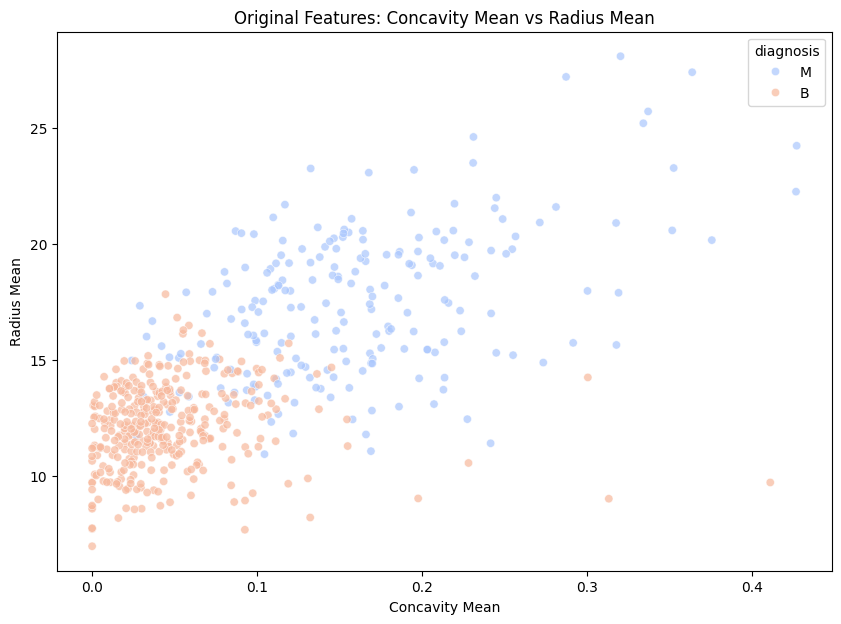

In [33]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['concavity_mean'],
    y=df['radius_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Concavity Mean vs Radius Mean")
plt.xlabel("Concavity Mean")
plt.ylabel("Radius Mean")
plt.show()

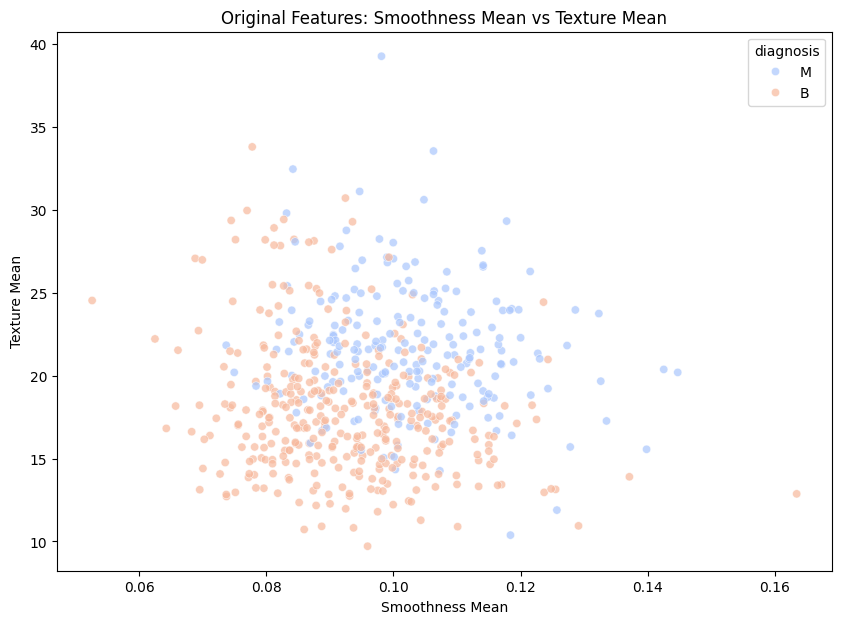

In [34]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['smoothness_mean'],
    y=df['texture_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Smoothness Mean vs Texture Mean")
plt.xlabel("Smoothness Mean")
plt.ylabel("Texture Mean")
plt.show()

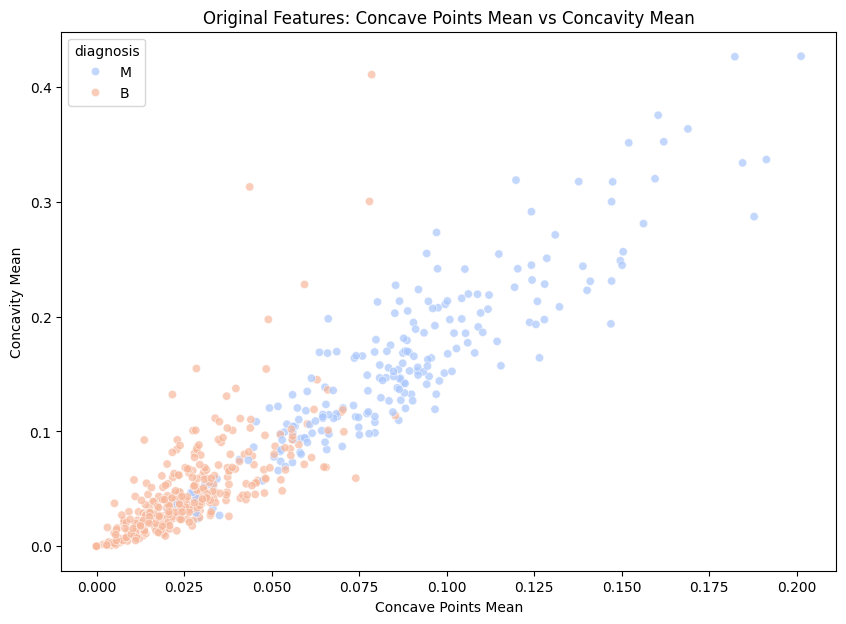

In [38]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['concave points_mean'],
    y=df['concavity_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Concave Points Mean vs Concavity Mean")
plt.xlabel("Concave Points Mean")
plt.ylabel("Concavity Mean")
plt.show()

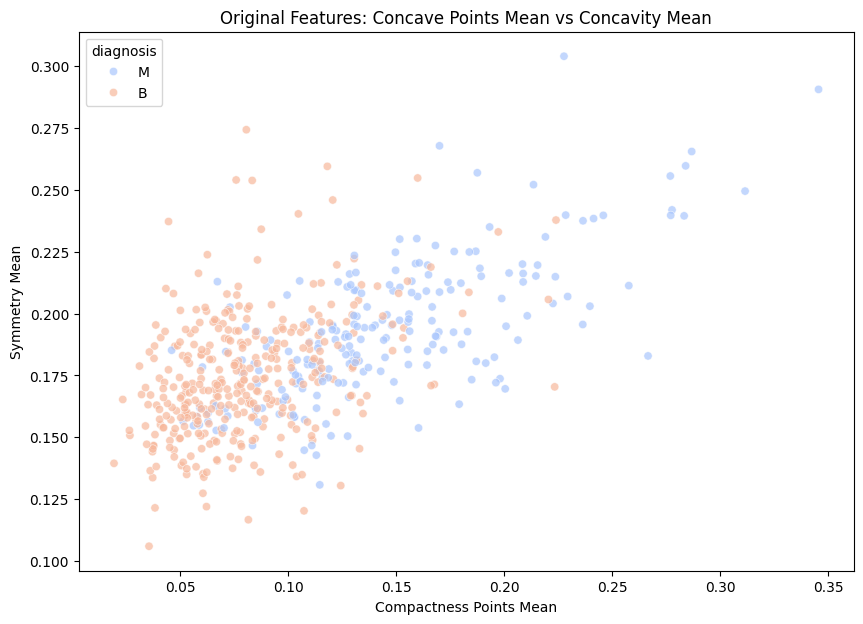

In [40]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df['compactness_mean'],
    y=df['symmetry_mean'],
    hue=df['diagnosis'],
    palette='coolwarm',
    alpha=0.7
    )
plt.title("Original Features: Concave Points Mean vs Concavity Mean")
plt.xlabel("Compactness Points Mean")
plt.ylabel("Symmetry Mean")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


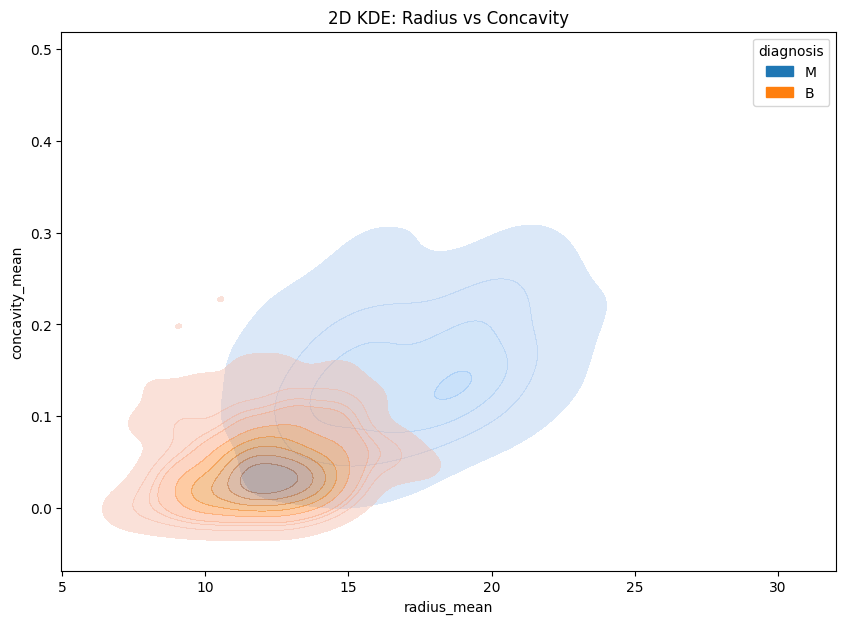

In [41]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="radius_mean",
    y="concavity_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Radius vs Concavity")
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


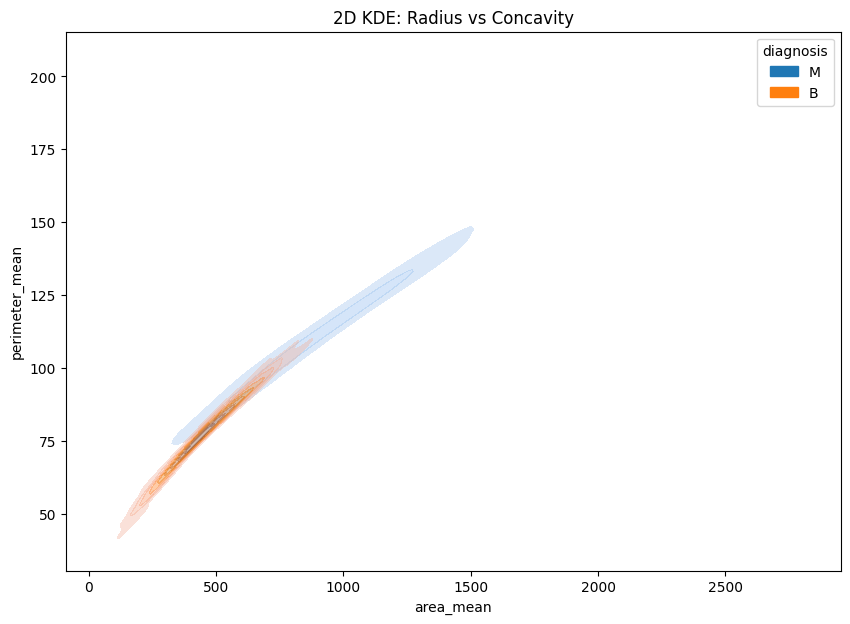

In [42]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="area_mean",
    y="perimeter_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Area vs Perimeter")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


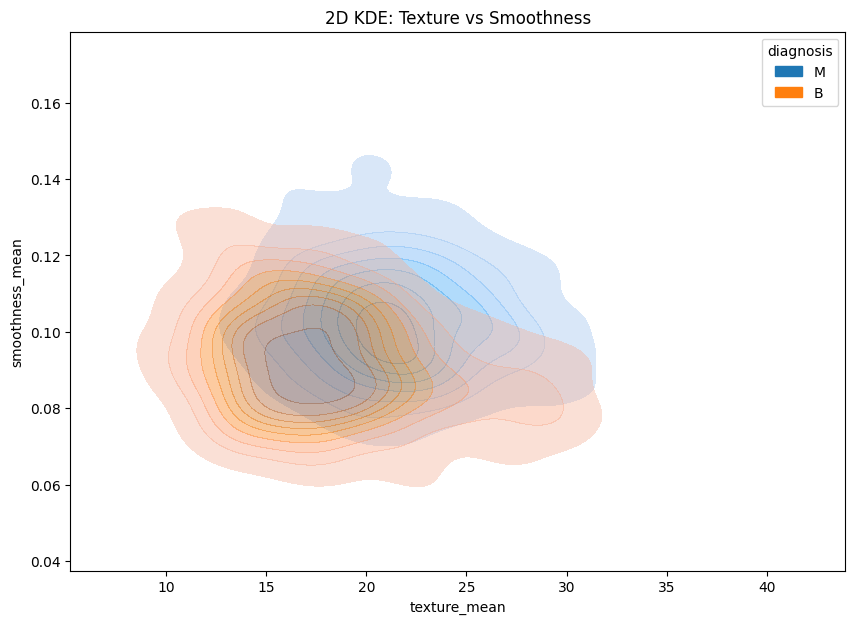

In [44]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="texture_mean",
    y="smoothness_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Texture vs Smoothness")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


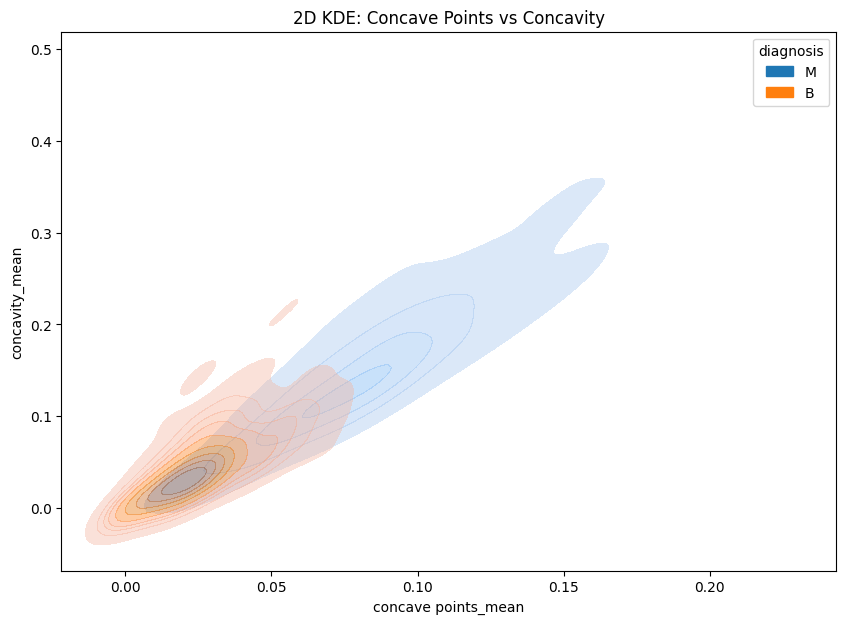

In [45]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="concave points_mean",
    y="concavity_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Concave Points vs Concavity")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


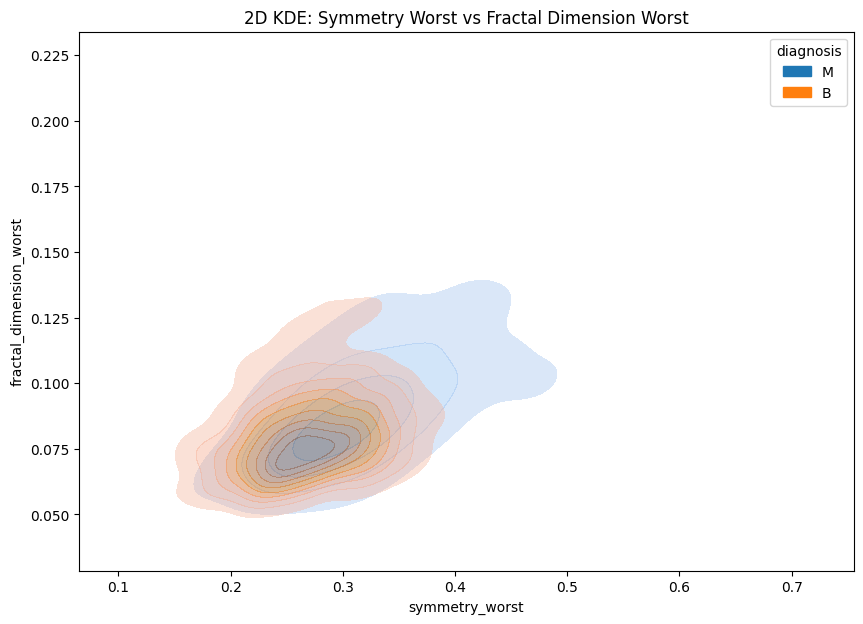

In [46]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="symmetry_worst",
    y="fractal_dimension_worst",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Symmetry Worst vs Fractal Dimension Worst")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


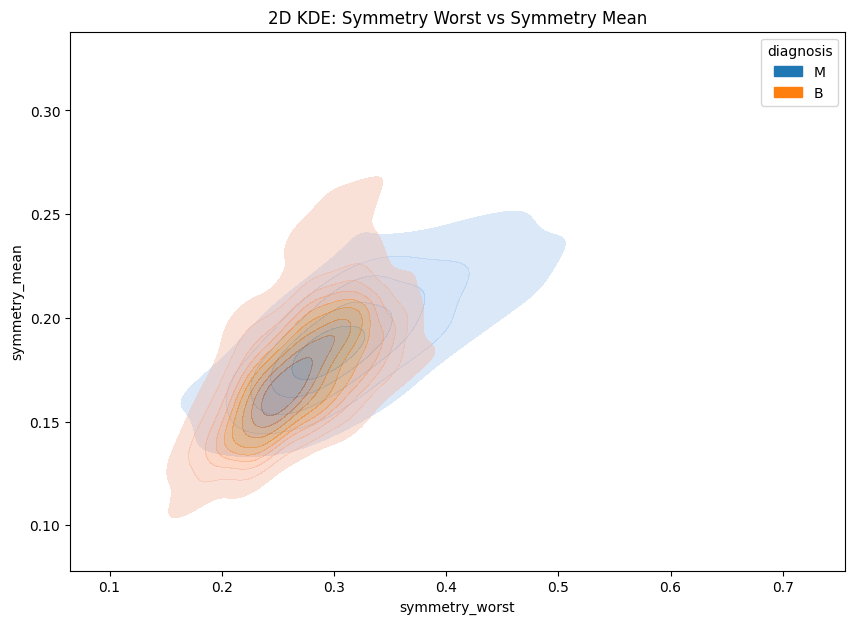

In [47]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="symmetry_worst",
    y="symmetry_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Symmetry Worst vs Symmetry Mean")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


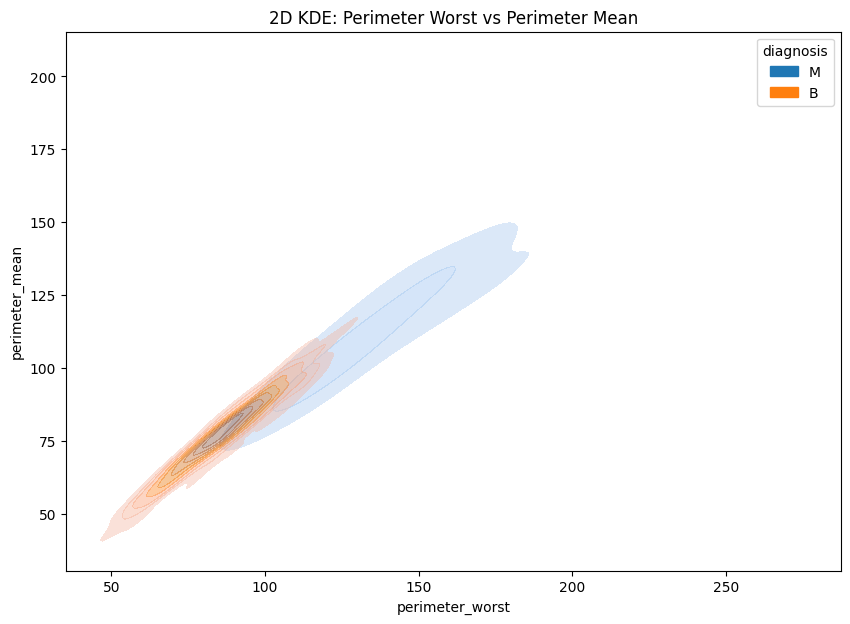

In [48]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="perimeter_worst",
    y="perimeter_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Perimeter Worst vs Perimeter Mean")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


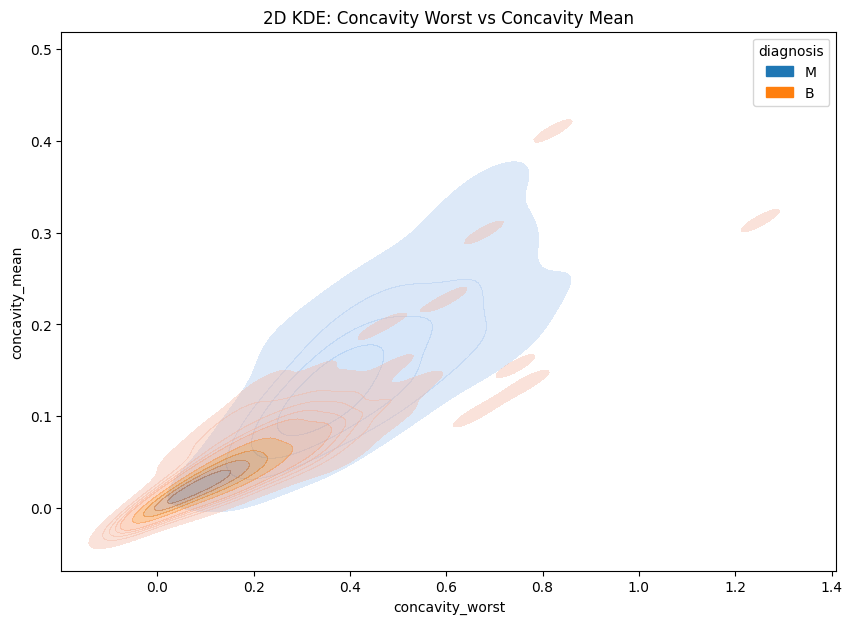

In [49]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="concavity_worst",
    y="concavity_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Concavity Worst vs Concavity Mean")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


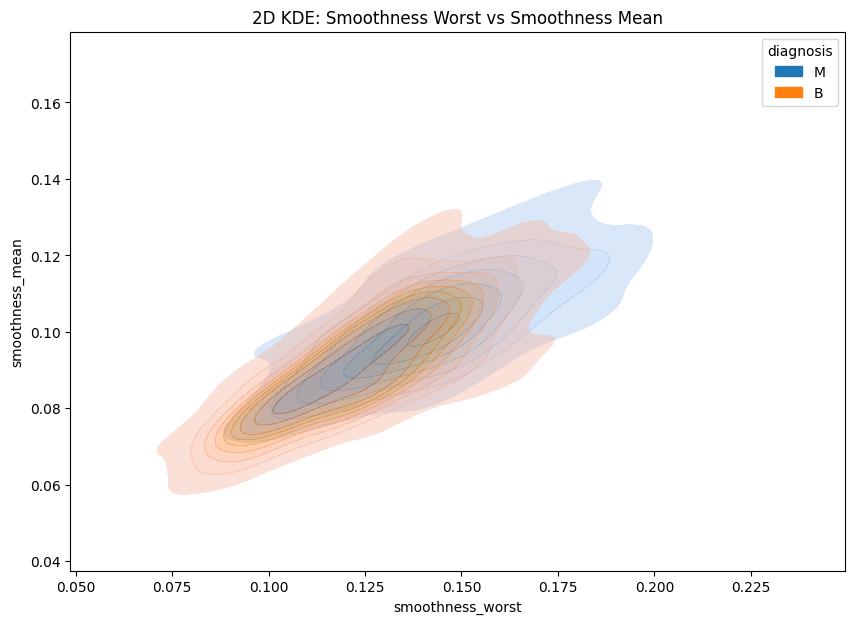

In [50]:
plt.figure(figsize=(10,7))
sns.kdeplot(
    data=df,
    x="smoothness_worst",
    y="smoothness_mean",
    hue="diagnosis",
    fill=True,
    alpha=0.4,
    thresh=0.05,
    levels=10,
    cmap="coolwarm"
)

plt.title("2D KDE: Smoothness Worst vs Smoothness Mean")
plt.show()

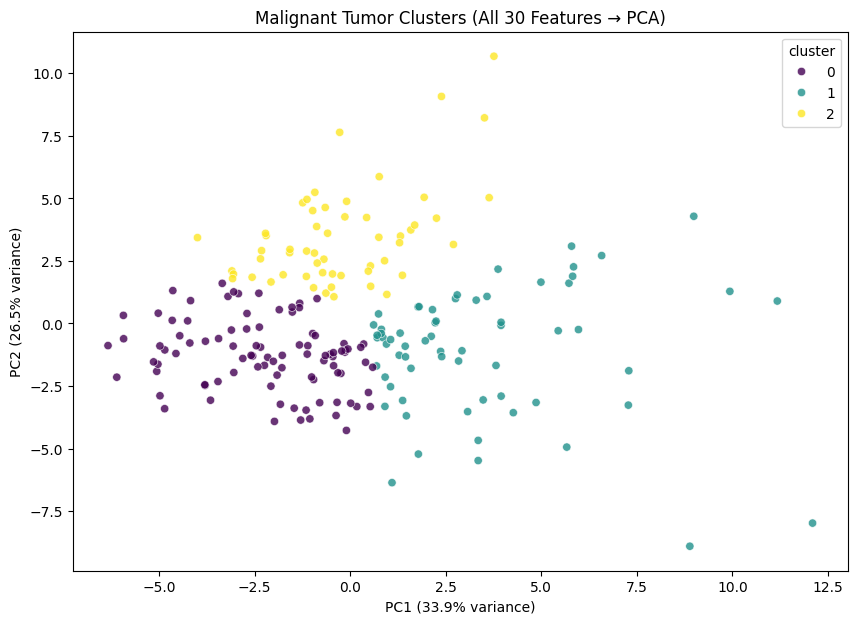

In [60]:
# 1. Filter malignant cases
malignant = df[df['diagnosis'] == 'M'].copy()

# 2. Drop non-feature columns
X_mal = malignant.drop(columns=['diagnosis'])

# 3. Scale features
scaler = StandardScaler()
X_mal_scaled = scaler.fit_transform(X_mal)

# 4. K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
malignant['cluster'] = kmeans.fit_predict(X_mal_scaled)

# 5. PCA for 2D visualization
pca = PCA(n_components=2)
pca_mal = pca.fit_transform(X_mal_scaled)

malignant['PC1'] = pca_mal[:, 0]
malignant['PC2'] = pca_mal[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=malignant,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    alpha=0.8
)

plt.title("Malignant Tumor Clusters (All 30 Features → PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()


         radius_mean  texture_mean  perimeter_mean  area_mean  \
cluster                                                         
0             17.202        21.386         112.078    935.994   
1             20.457        22.165         136.730   1323.153   
2             14.419        21.323          96.063    648.847   

         smoothness_mean  compactness_mean  concavity_mean  \
cluster                                                      
0                  0.094             0.104           0.108   
1                  0.107             0.181           0.227   
2                  0.113             0.174           0.174   

         concave points_mean  symmetry_mean  fractal_dimension_mean  ...  \
cluster                                                              ...   
0                      0.067          0.178                   0.058  ...   
1                      0.123          0.201                   0.063  ...   
2                      0.083          0.210                

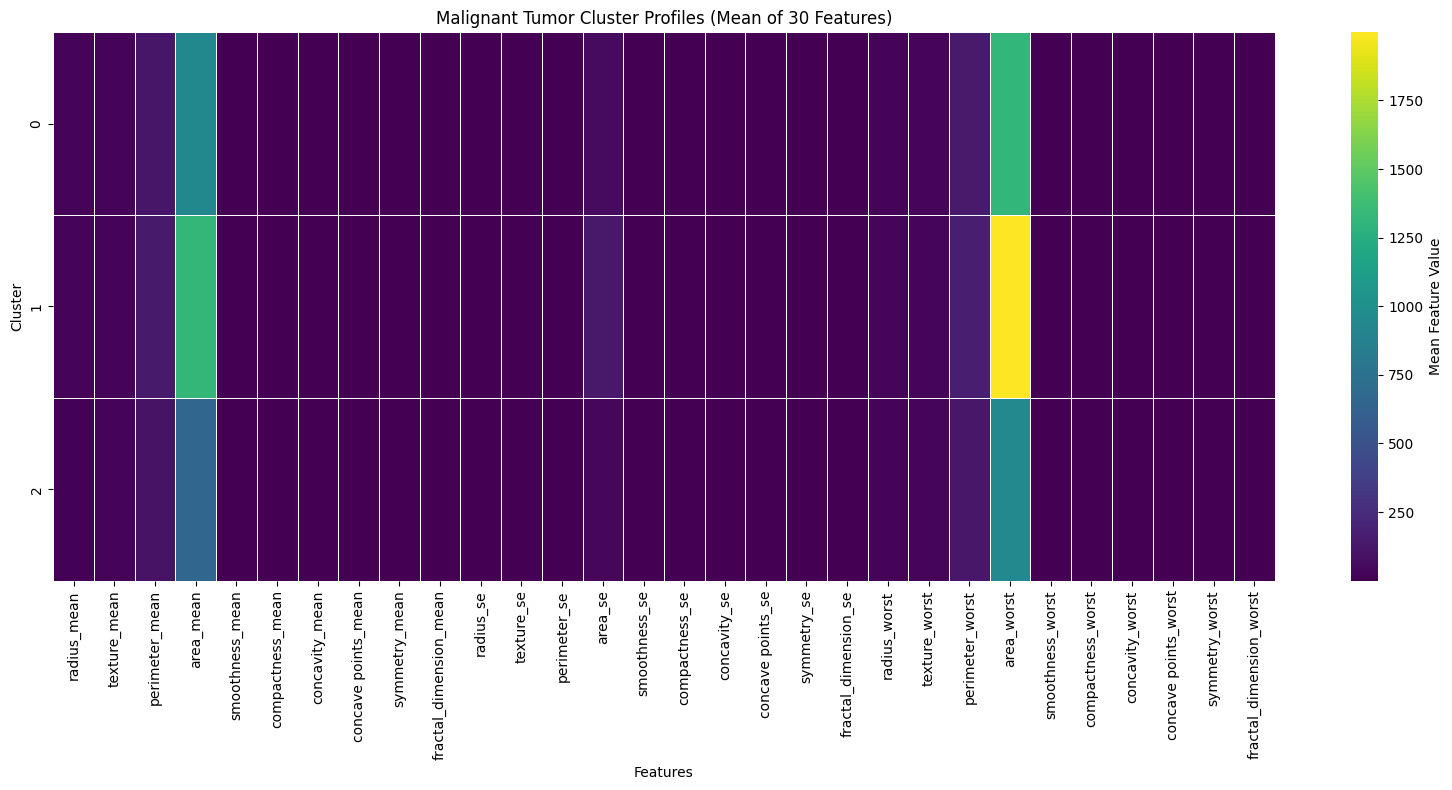

In [67]:
# ---------------------------------------------
# 1. Compute cluster feature means
# ---------------------------------------------
cluster_profile = (
    malignant
    .drop(columns=['diagnosis', 'PC1', 'PC2'], errors='ignore')
    .groupby('cluster')
    .mean()
    .round(3)
)

print(cluster_profile)

# ---------------------------------------------
# 2. Plot heatmap
# ---------------------------------------------
plt.figure(figsize=(16, 8))
sns.heatmap(
    cluster_profile,
    cmap="viridis",
    annot=False,
    linewidths=0.5,
    cbar_kws={"label": "Mean Feature Value"}
)

plt.title("Malignant Tumor Cluster Profiles (Mean of 30 Features)")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


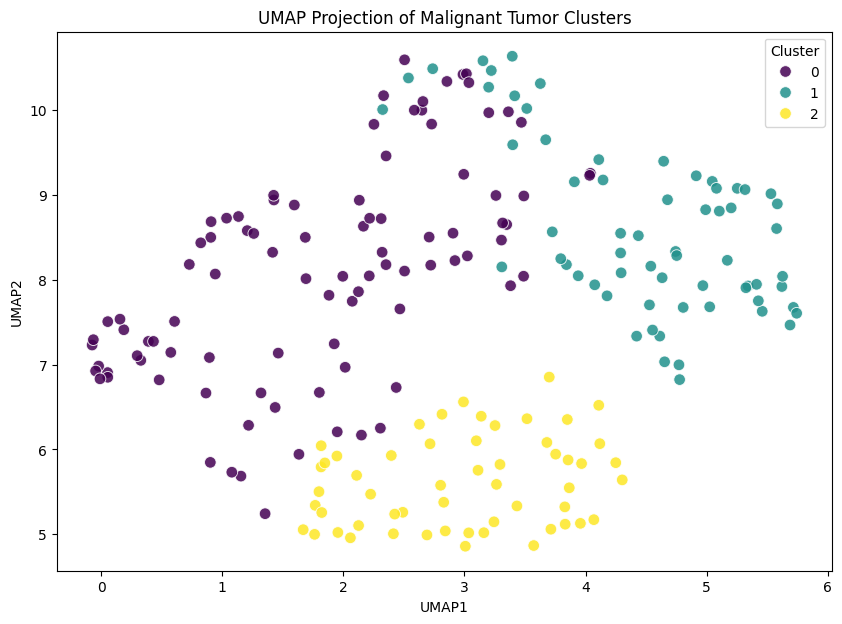

In [68]:
# Install UMAP if needed
!pip install umap-learn

import umap
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Prepare malignant feature matrix
# ---------------------------------------------
X_mal = malignant.drop(columns=['id', 'diagnosis', 'cluster', 'PC1', 'PC2'], errors='ignore')

# ---------------------------------------------
# 2. Scale features
# ---------------------------------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_mal_scaled = scaler.fit_transform(X_mal)

# ---------------------------------------------
# 3. Run UMAP
# ---------------------------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

umap_2d = umap_model.fit_transform(X_mal_scaled)

malignant['UMAP1'] = umap_2d[:, 0]
malignant['UMAP2'] = umap_2d[:, 1]

# ---------------------------------------------
# 4. Plot UMAP clusters
# ---------------------------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=malignant,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='viridis',
    s=70,
    alpha=0.85
)

plt.title("UMAP Projection of Malignant Tumor Clusters")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster")
plt.show()

/tmp/ipykernel_299/3133237116.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


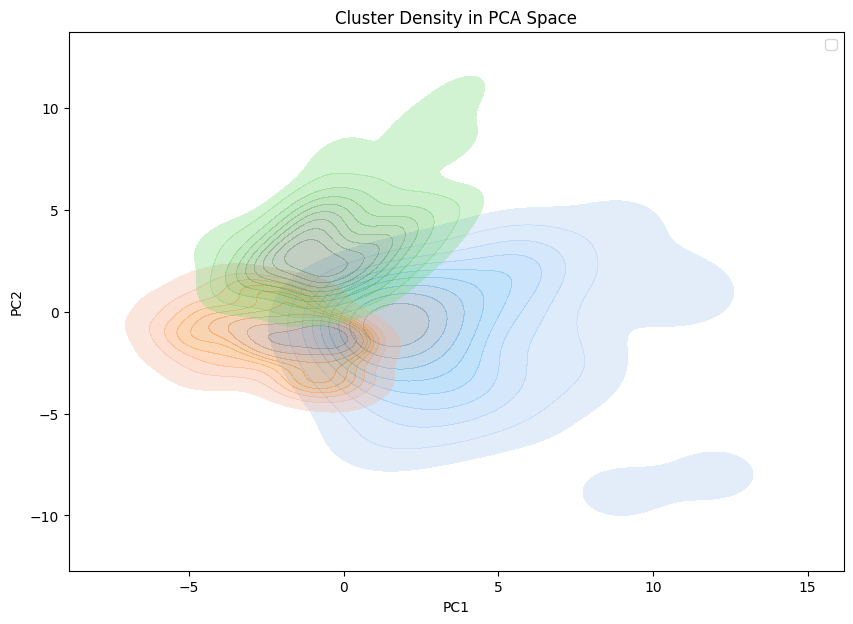

In [69]:
plt.figure(figsize=(10,7))
for c in malignant['cluster'].unique():
    sns.kdeplot(
        data=malignant[malignant['cluster']==c],
        x='PC1',
        y='PC2',
        fill=True,
        alpha=0.3,
        label=f"Cluster {c}"
    )
plt.title("Cluster Density in PCA Space")
plt.legend()
plt.show()

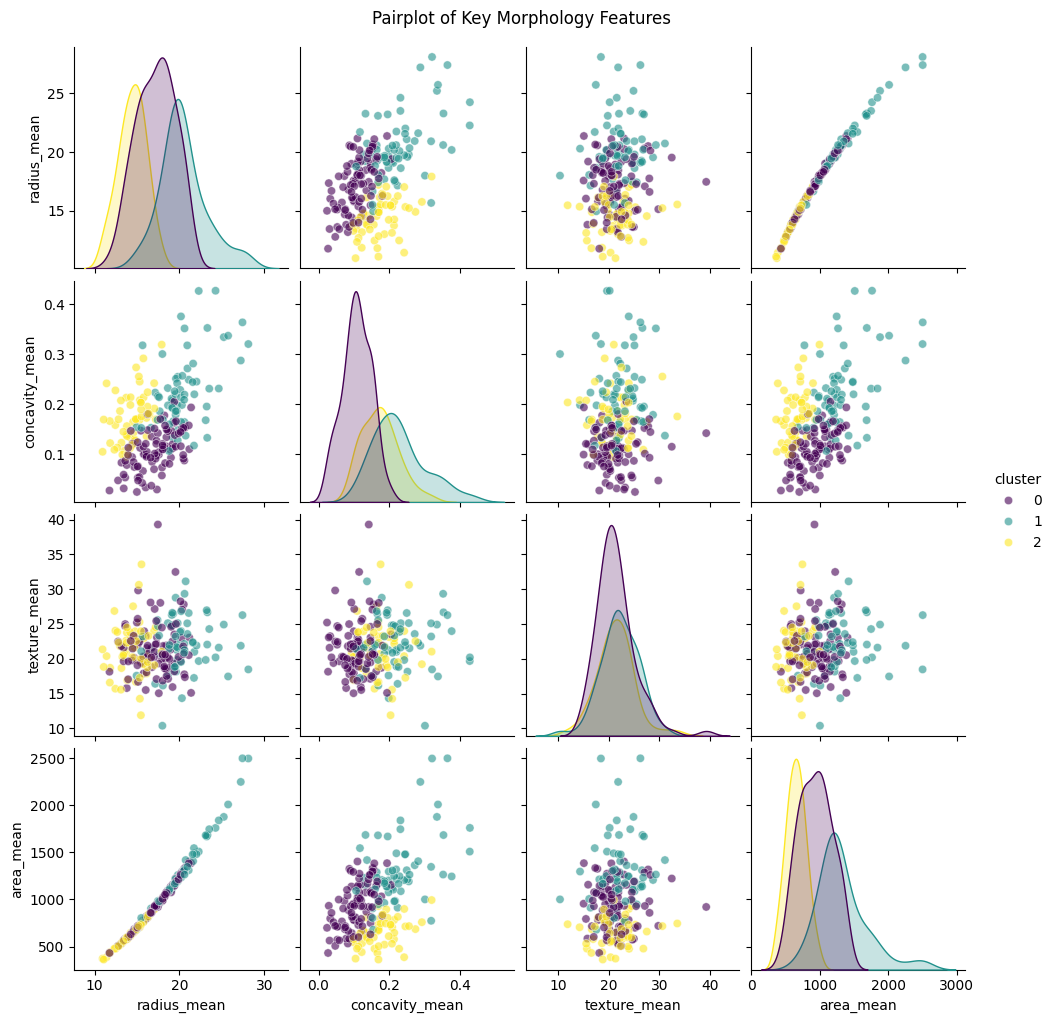

In [70]:
sns.pairplot(
    malignant,
    vars=["radius_mean","concavity_mean","texture_mean","area_mean"],
    hue="cluster",
    palette="viridis",
    diag_kind="kde",
    plot_kws={"alpha":0.6}
)
plt.suptitle("Pairplot of Key Morphology Features", y=1.02)
plt.show()

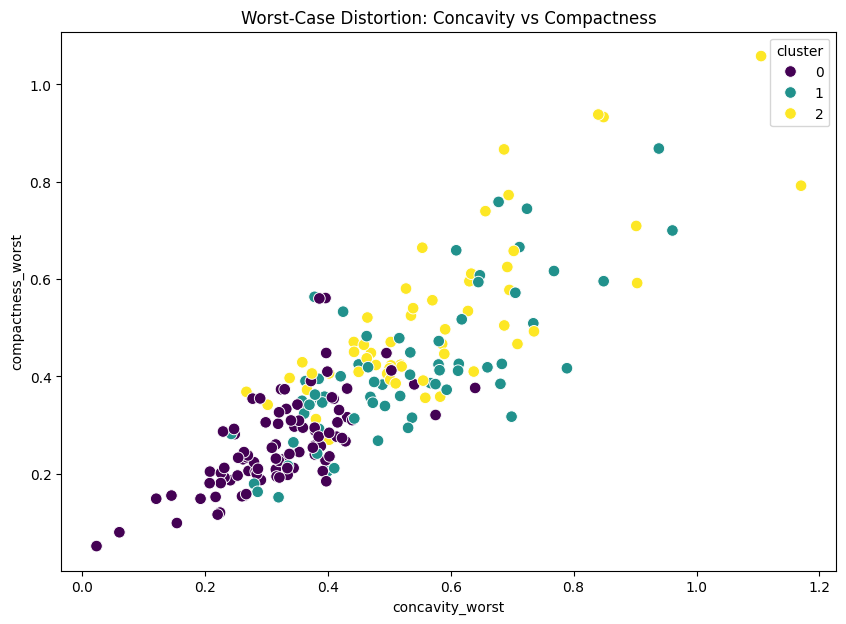

In [71]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=malignant,
    x='concavity_worst',
    y='compactness_worst',
    hue='cluster',
    palette='viridis',
    s=70
)
plt.title("Worst-Case Distortion: Concavity vs Compactness")
plt.show()

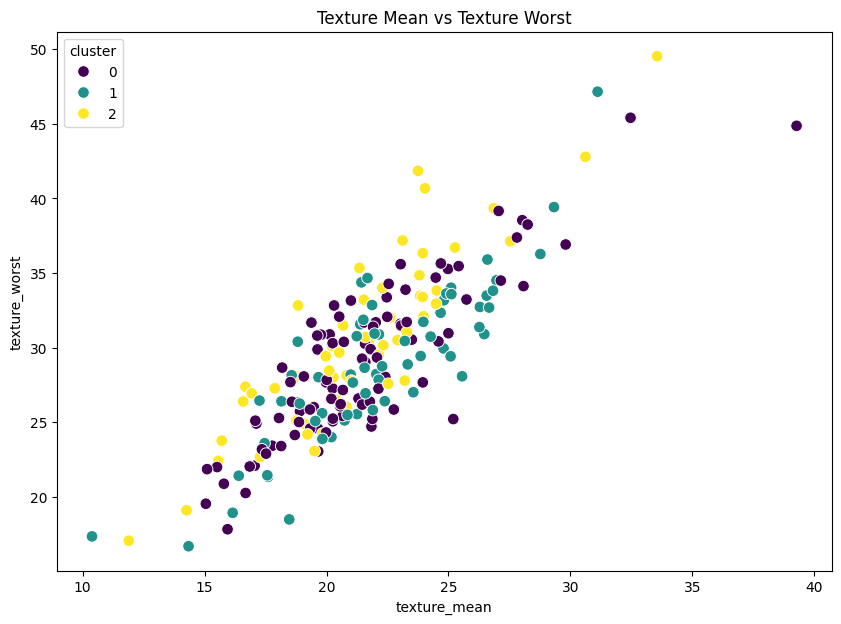

In [72]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=malignant,
    x='texture_mean',
    y='texture_worst',
    hue='cluster',
    palette='viridis',
    s=70
)
plt.title("Texture Mean vs Texture Worst")
plt.show()

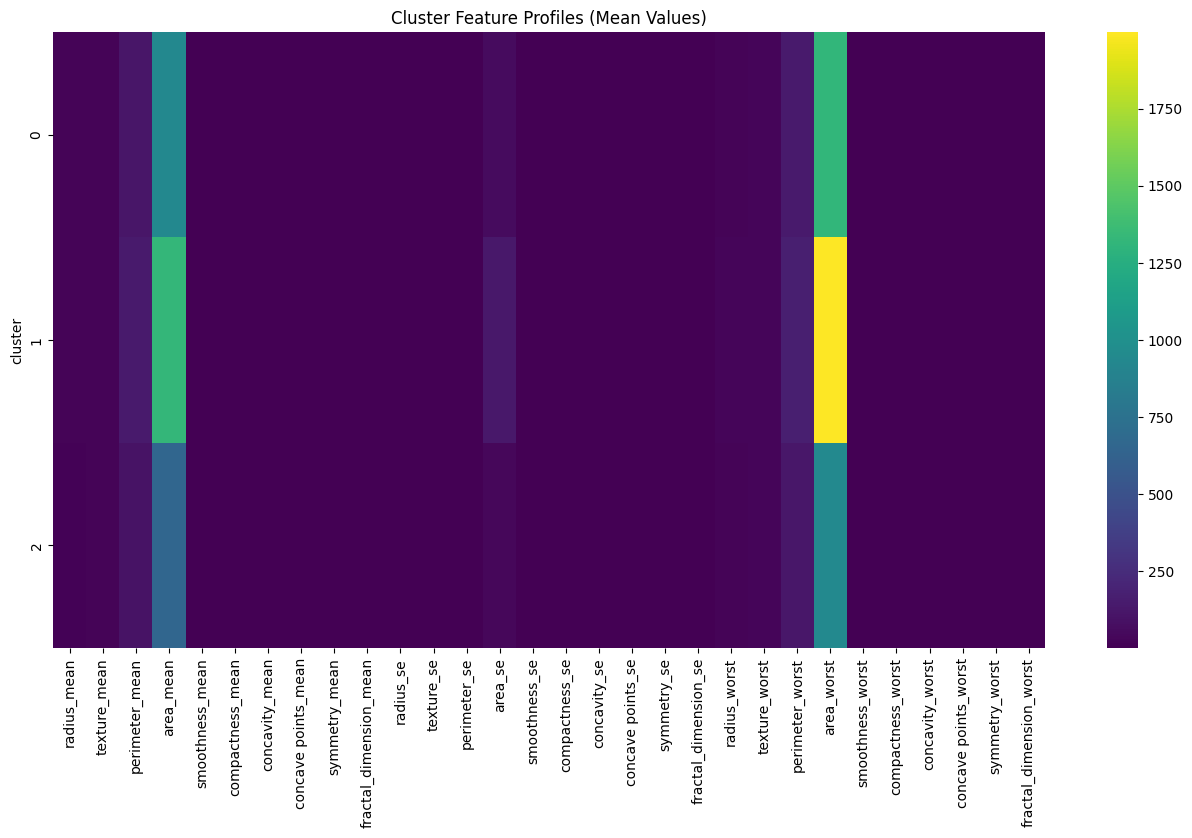

In [73]:
cluster_profile = (
    malignant
    .drop(columns=['id','diagnosis','PC1','PC2','UMAP1','UMAP2'], errors='ignore')
    .groupby('cluster')
    .mean()
)

plt.figure(figsize=(16,8))
sns.heatmap(cluster_profile, cmap='viridis')
plt.title("Cluster Feature Profiles (Mean Values)")
plt.show()

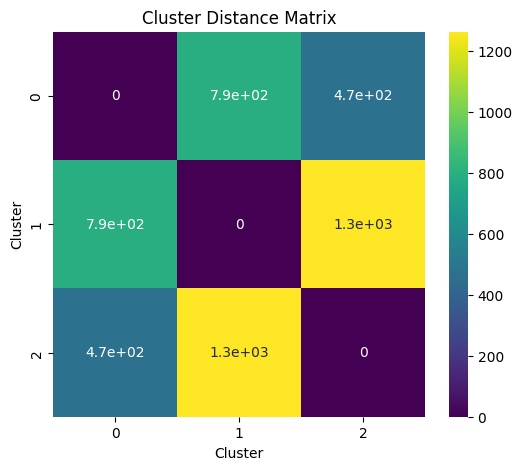

In [75]:
from scipy.spatial.distance import pdist, squareform

centroids = cluster_profile.values
dist_matrix = squareform(pdist(centroids))

plt.figure(figsize=(6,5))
sns.heatmap(dist_matrix, annot=True, cmap='viridis')
plt.title("Cluster Distance Matrix")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

/tmp/ipykernel_299/2620994033.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


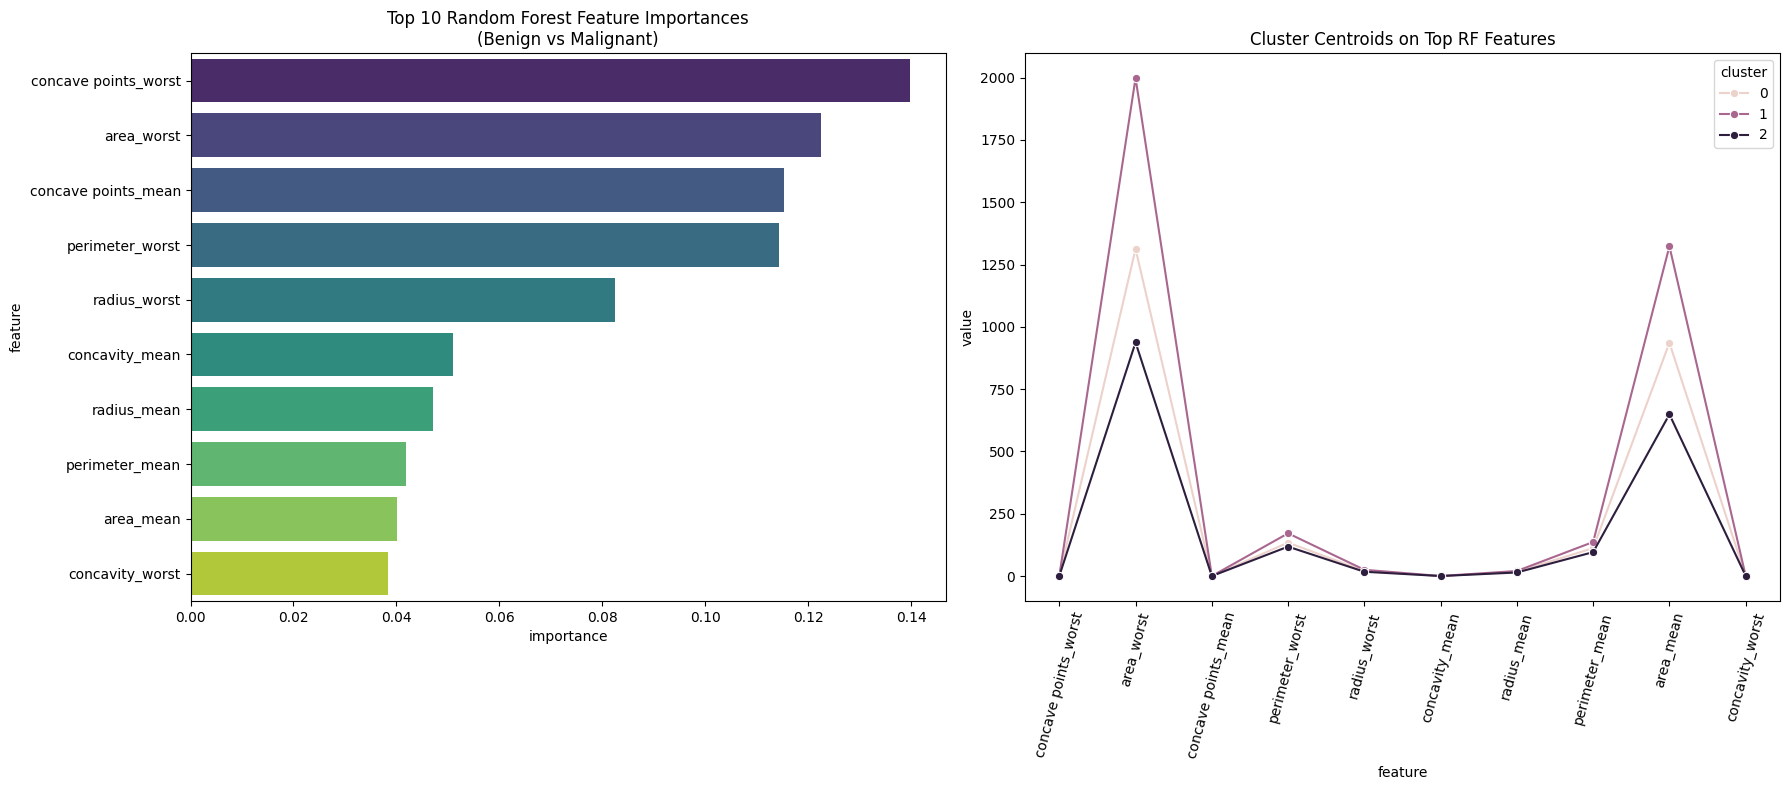

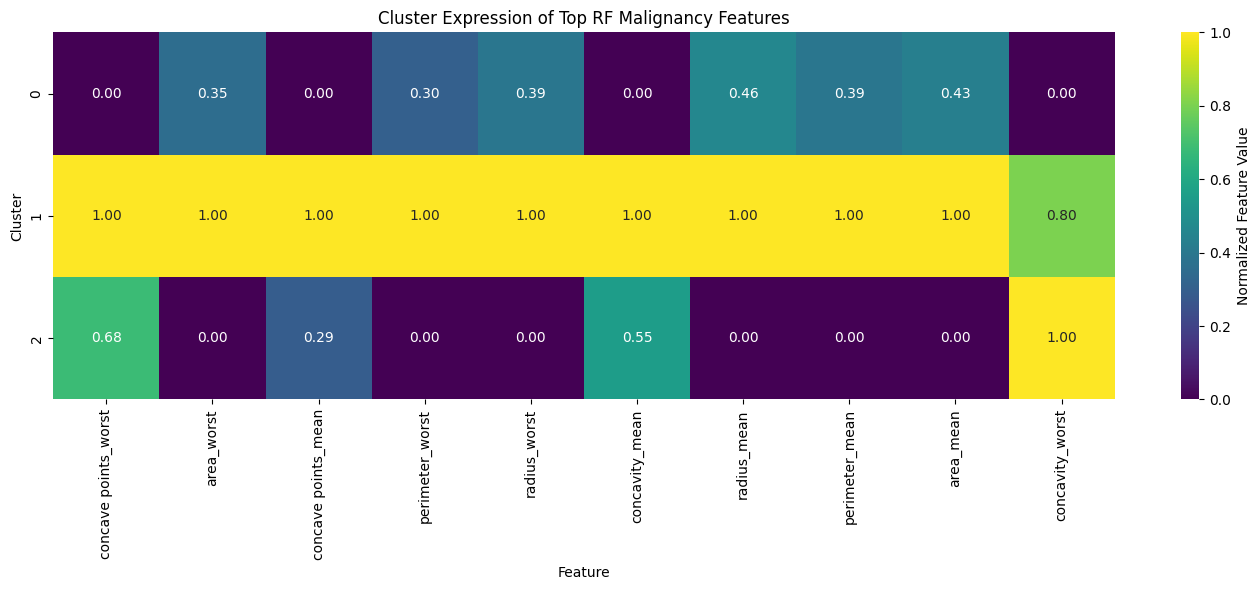

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importances.head(10)['feature'].tolist()

cluster_centroids = (
    malignant.groupby('cluster')[top_features]
    .mean()
    .reset_index()
    .melt(id_vars='cluster', var_name='feature', value_name='value')
)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: RF importance
sns.barplot(
    data=importances.head(10),
    x='importance',
    y='feature',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Top 10 Random Forest Feature Importances\n(Benign vs Malignant)")

# Right: Cluster centroids
sns.lineplot(
    data=cluster_centroids,
    x='feature',
    y='value',
    hue='cluster',
    marker='o',
    ax=axes[1]
)
axes[1].set_title("Cluster Centroids on Top RF Features")
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

cluster_top = malignant.groupby('cluster')[top_features].mean()

# Normalize for contrast
cluster_top_norm = (cluster_top - cluster_top.min()) / (cluster_top.max() - cluster_top.min())

plt.figure(figsize=(14, 6))
sns.heatmap(
    cluster_top_norm,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Normalized Feature Value'}
)
plt.title("Cluster Expression of Top RF Malignancy Features")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


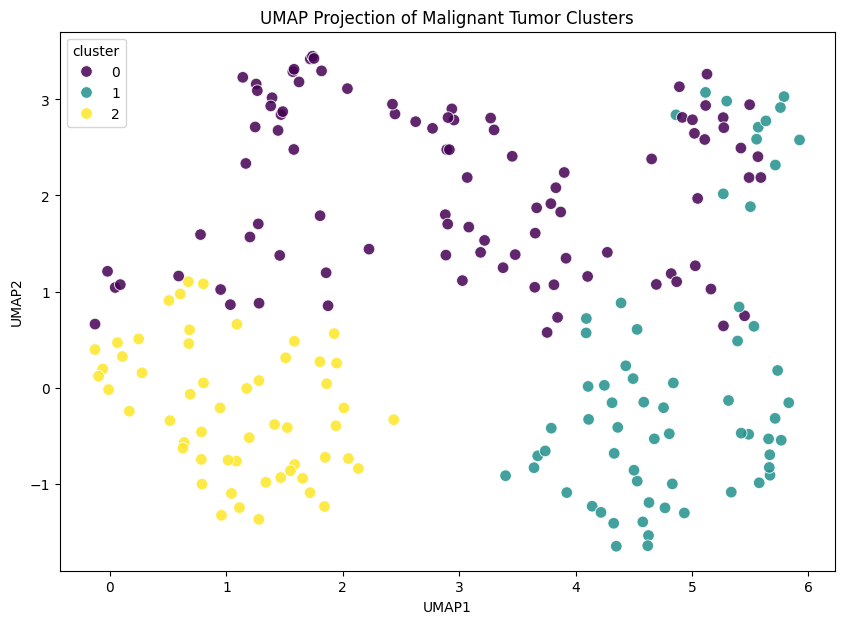

In [80]:
import umap
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare malignant features
X_mal = malignant.drop(columns=['id','diagnosis','cluster','PC1','PC2'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mal)

# UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
umap_2d = umap_model.fit_transform(X_scaled)

malignant['UMAP1'] = umap_2d[:,0]
malignant['UMAP2'] = umap_2d[:,1]

# Plot
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=malignant,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='viridis',
    s=70,
    alpha=0.85
)
plt.title("UMAP Projection of Malignant Tumor Clusters")
plt.show()

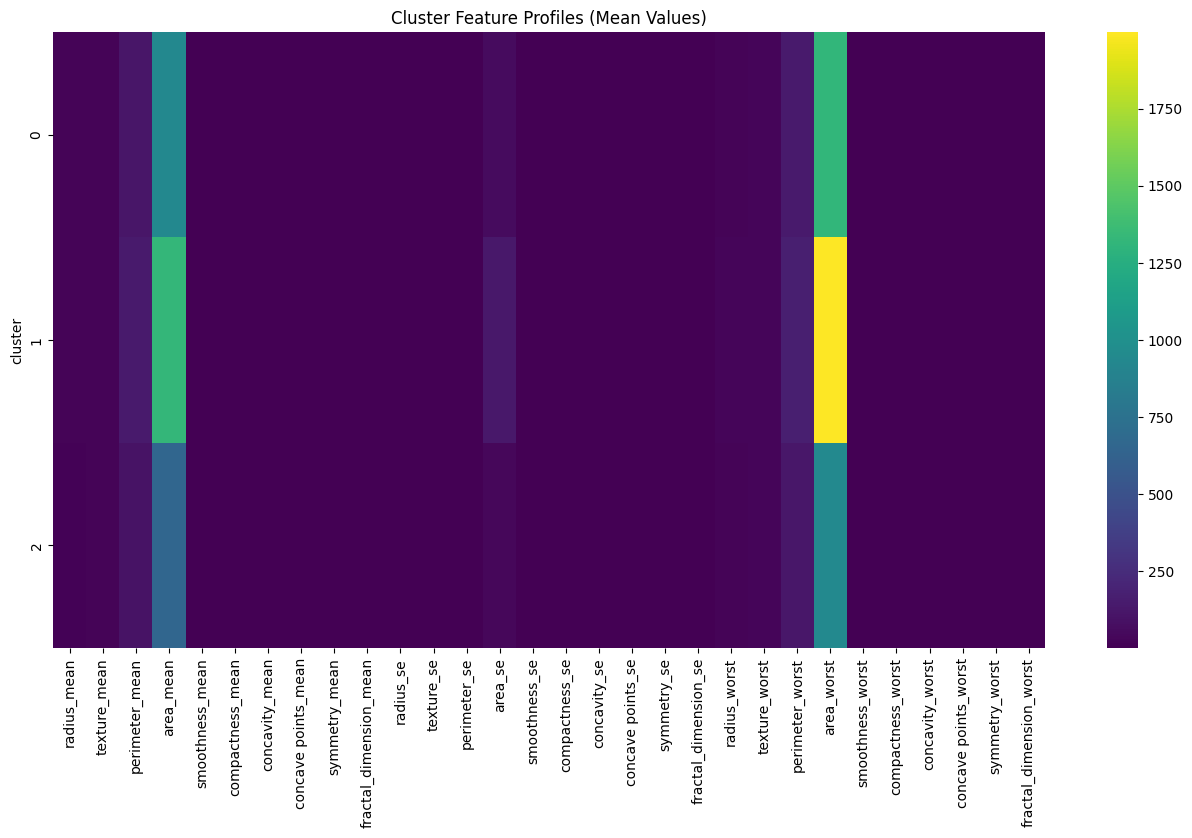

In [81]:
cluster_profile = (
    malignant
    .drop(columns=['id','diagnosis','PC1','PC2','UMAP1','UMAP2'], errors='ignore')
    .groupby('cluster')
    .mean()
)

plt.figure(figsize=(16,8))
sns.heatmap(cluster_profile, cmap='viridis')
plt.title("Cluster Feature Profiles (Mean Values)")
plt.show()

/tmp/ipykernel_299/2126775643.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


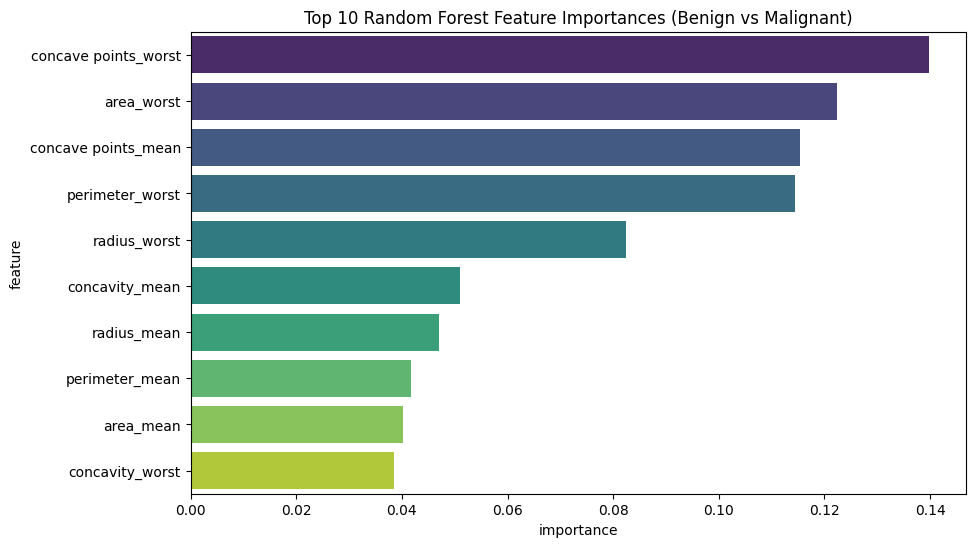

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare full dataset
X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importances.head(10)['feature'].tolist()

plt.figure(figsize=(10,6))
sns.barplot(
    data=importances.head(10),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title("Top 10 Random Forest Feature Importances (Benign vs Malignant)")
plt.show()

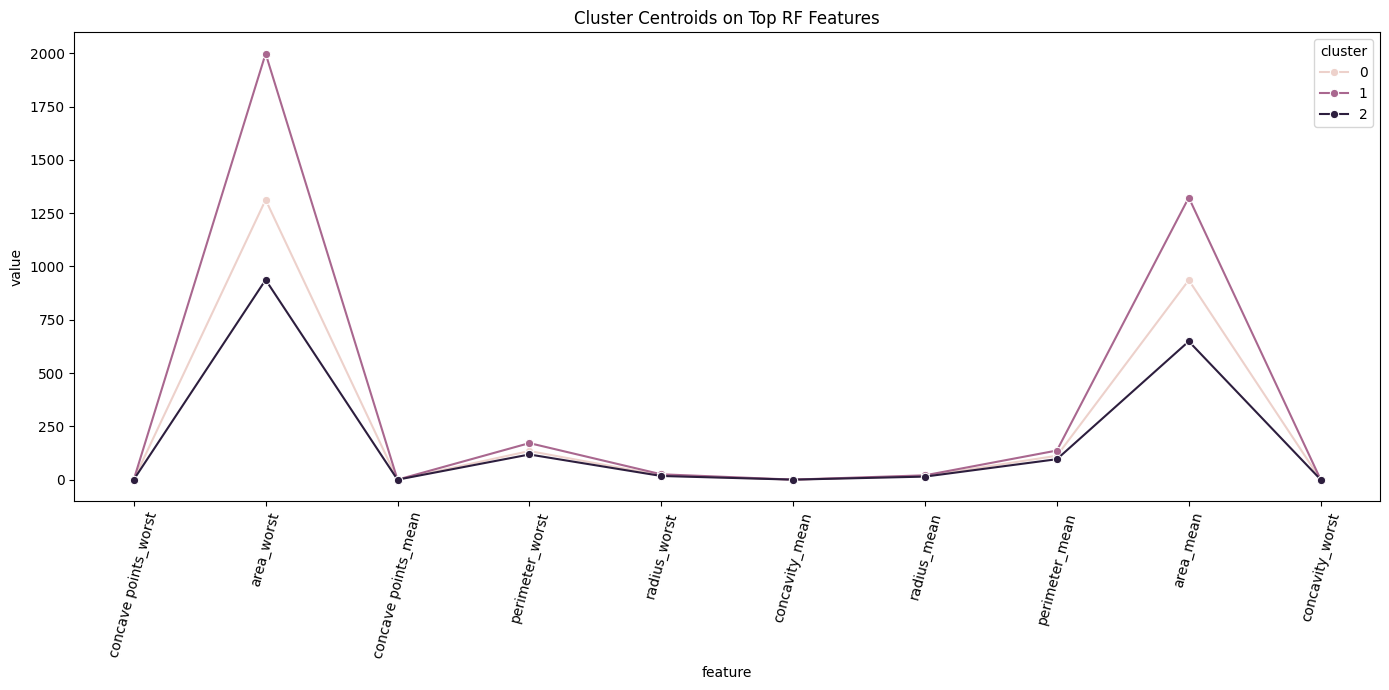

In [84]:
# Compute cluster centroids for top RF features
cluster_centroids = (
    malignant.groupby('cluster')[top_features]
    .mean()
    .reset_index()
    .melt(id_vars='cluster', var_name='feature', value_name='value')
)

plt.figure(figsize=(14,7))
sns.lineplot(
    data=cluster_centroids,
    x='feature',
    y='value',
    hue='cluster',
    marker='o'
)
plt.title("Cluster Centroids on Top RF Features")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

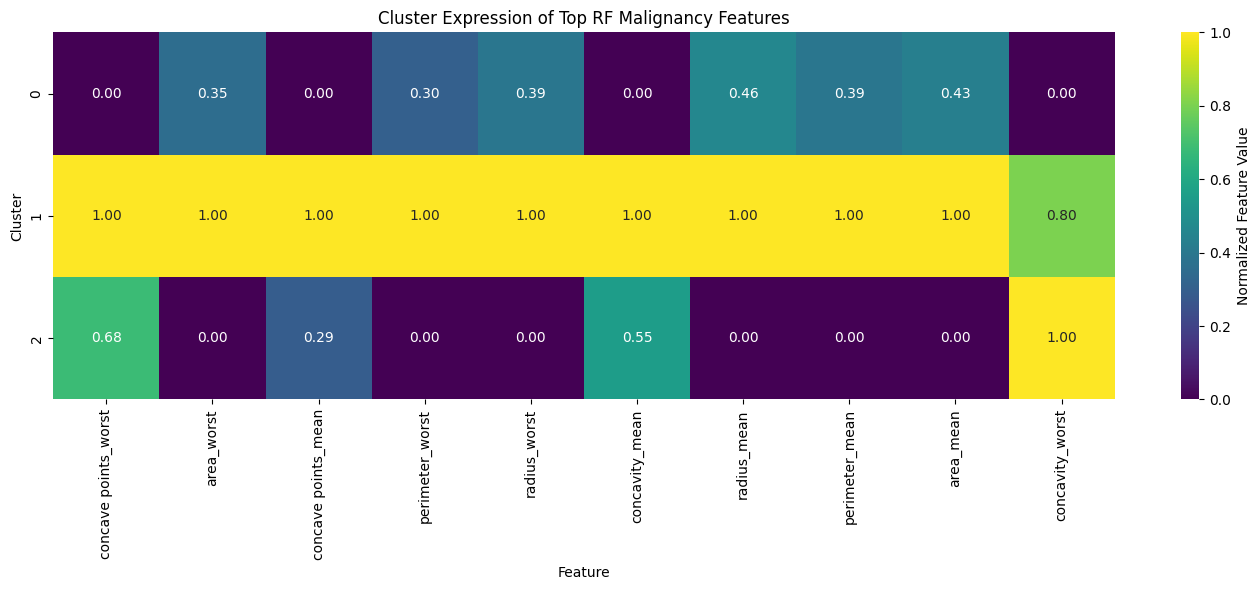

In [87]:
cluster_top = malignant.groupby('cluster')[top_features].mean()

# Normalize for contrast
cluster_top_norm = (cluster_top - cluster_top.min()) / (cluster_top.max() - cluster_top.min())

plt.figure(figsize=(14,6))
sns.heatmap(
    cluster_top_norm,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Normalized Feature Value'}
)
plt.title("Cluster Expression of Top RF Malignancy Features")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()